# EuroSAT-MS Data Exploration

This notebook provides a compact but informative exploration of one EuroSAT-MS sample before building the dataloader and baseline. It focuses on:

- locating and opening one multispectral `.tif` file,
- inspecting metadata and per-band statistics,
- visualizing RGB and false-color composites,
- reviewing all 13 Sentinel-2 bands,
- checking spectral distribution and band correlation.

The goal is to understand what the model will later receive as input: a **13-channel Sentinel-2 patch** of shape `(13, 64, 64)`.


## 1. Import libraries

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from pathlib import Path

## 2. Locate the dataset and select one sample image

In [48]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data" / "EuroSAT_MS"

sample_class = "Forest"
data_dir = DATA_ROOT / sample_class
tif_files = sorted(data_dir.rglob("*.tif"))

#print("PROJECT_ROOT:", PROJECT_ROOT)
#print("DATA_ROOT:", DATA_ROOT)
print(f"Number of .tif files found in '{sample_class}': {len(tif_files)}")

sample_path = tif_files[0]
#print("Sample file:", sample_path)

Number of .tif files found in 'Forest': 3000


## 3. Read the multispectral GeoTIFF image

In [49]:
with rasterio.open(sample_path) as src:
    img = src.read()
    profile = src.profile

print("Image shape:", img.shape)
print("Data type:", img.dtype)
print("Raster profile:")
print(profile)

Image shape: (13, 64, 64)
Data type: uint16
Raster profile:
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 64, 'height': 64, 'count': 13, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32632"]]'), 'transform': Affine(10.005196165071764, 0.0, 533043.6787387297,
       0.0, -10.008080018868775, 5567792.427645094), 'blockxsize': 64, 'blockysize': 4, 'tiled': False, 'interleave': 'pixel'}


## 4. Extract the class label

In [50]:
label = sample_path.parent.name
print("Label:", label)

Label: Forest


## 5. Inspect per-band statistics

In [51]:
print("Per-band statistics:")
for b in range(img.shape[0]):
    band = img[b]
    print(
        f"Band {b+1:02d} | "
        f"min={band.min()}, "
        f"max={band.max()}, "
        f"mean={band.mean():.2f}, "
        f"std={band.std():.2f}"
    )

Per-band statistics:
Band 01 | min=1138, max=1161, mean=1149.48, std=4.61
Band 02 | min=776, max=1009, mean=831.31, std=18.45
Band 03 | min=525, max=917, mean=652.27, std=41.53
Band 04 | min=326, max=711, mean=410.17, std=35.01
Band 05 | min=475, max=863, mean=659.03, std=67.90
Band 06 | min=1147, max=3085, mean=1998.10, std=339.98
Band 07 | min=1445, max=4386, mean=2707.45, std=519.51
Band 08 | min=1021, max=4782, mean=2612.36, std=625.29
Band 09 | min=372, max=801, mean=579.30, std=87.73
Band 10 | min=7, max=10, mean=8.45, std=0.75
Band 11 | min=632, max=1957, mean=1304.69, std=237.92
Band 12 | min=242, max=726, mean=496.32, std=87.56
Band 13 | min=1640, max=5087, mean=3114.87, std=611.42


## 6. Normalization function for visualization

In [52]:
def normalize_band(x, lower=2, upper=98):
    x = x.astype("float32")
    lo, hi = np.percentile(x, (lower, upper))
    x = np.clip((x - lo) / (hi - lo + 1e-8), 0, 1)
    return x

## 7. Visualize an RGB composite image

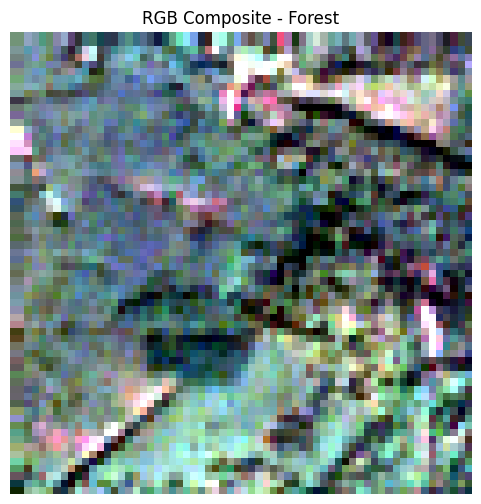

In [53]:
r = normalize_band(img[3])  # B04 = Red
g = normalize_band(img[2])  # B03 = Green
b = normalize_band(img[1])  # B02 = Blue

rgb = np.stack([r, g, b], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(rgb)
plt.title(f"RGB Composite - {label}")
plt.axis("off")
plt.show()

## 8. Visualize a false-color composite image

A common remote-sensing false-color composite uses **NIR-Red-Green** (`B08`, `B04`, `B03`).
Vegetation usually appears brighter or more saturated in this view than in natural RGB.


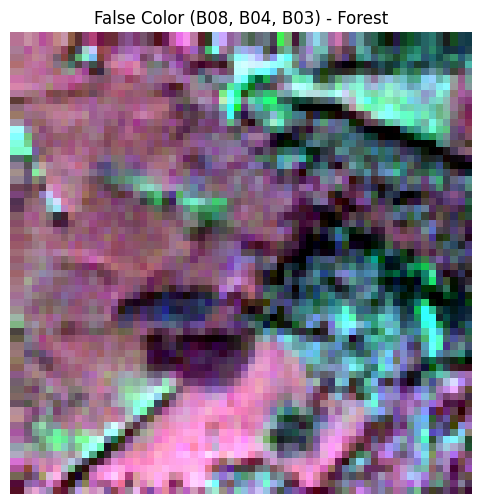

In [54]:
nir = normalize_band(img[7])   # B08 = NIR
red = normalize_band(img[3])   # B04 = Red
green = normalize_band(img[2]) # B03 = Green

false_color = np.stack([nir, red, green], axis=-1)

plt.figure(figsize=(6, 6))
plt.imshow(false_color)
plt.title(f"False Color (B08, B04, B03) - {label}")
plt.axis("off")
plt.show()

## 9. Define Sentinel-2 band names and reference information

EuroSAT-MS uses 13 Sentinel-2 bands. The table below is useful because the bands do not all represent the same part of the spectrum.

| Band | Common name | Center wavelength (nm) | Native resolution (m) |
|---|---|---:|---:|
| B01 | Coastal aerosol | 443 | 60 |
| B02 | Blue | 490 | 10 |
| B03 | Green | 560 | 10 |
| B04 | Red | 665 | 10 |
| B05 | Vegetation Red Edge 1 | 705 | 20 |
| B06 | Vegetation Red Edge 2 | 740 | 20 |
| B07 | Vegetation Red Edge 3 | 783 | 20 |
| B08 | NIR | 842 | 10 |
| B8A | Narrow NIR / Red Edge 4 | 865 | 20 |
| B09 | Water vapour | 945 | 60 |
| B10 | Cirrus | 1375 | 60 |
| B11 | SWIR 1 | 1610 | 20 |
| B12 | SWIR 2 | 2190 | 20 |


In [55]:
band_names = [
    "B01", "B02", "B03", "B04", "B05", "B06", "B07",
    "B08", "B8A", "B09", "B10", "B11", "B12"
]

band_long_names = [
    "Coastal aerosol", "Blue", "Green", "Red", "Vegetation Red Edge 1",
    "Vegetation Red Edge 2", "Vegetation Red Edge 3", "NIR",
    "Narrow NIR / Red Edge 4", "Water vapour", "Cirrus", "SWIR 1", "SWIR 2"
]

wavelengths_nm = [443, 490, 560, 665, 705, 740, 783, 842, 865, 945, 1375, 1610, 2190]

## 10. Visualize all 13 spectral bands

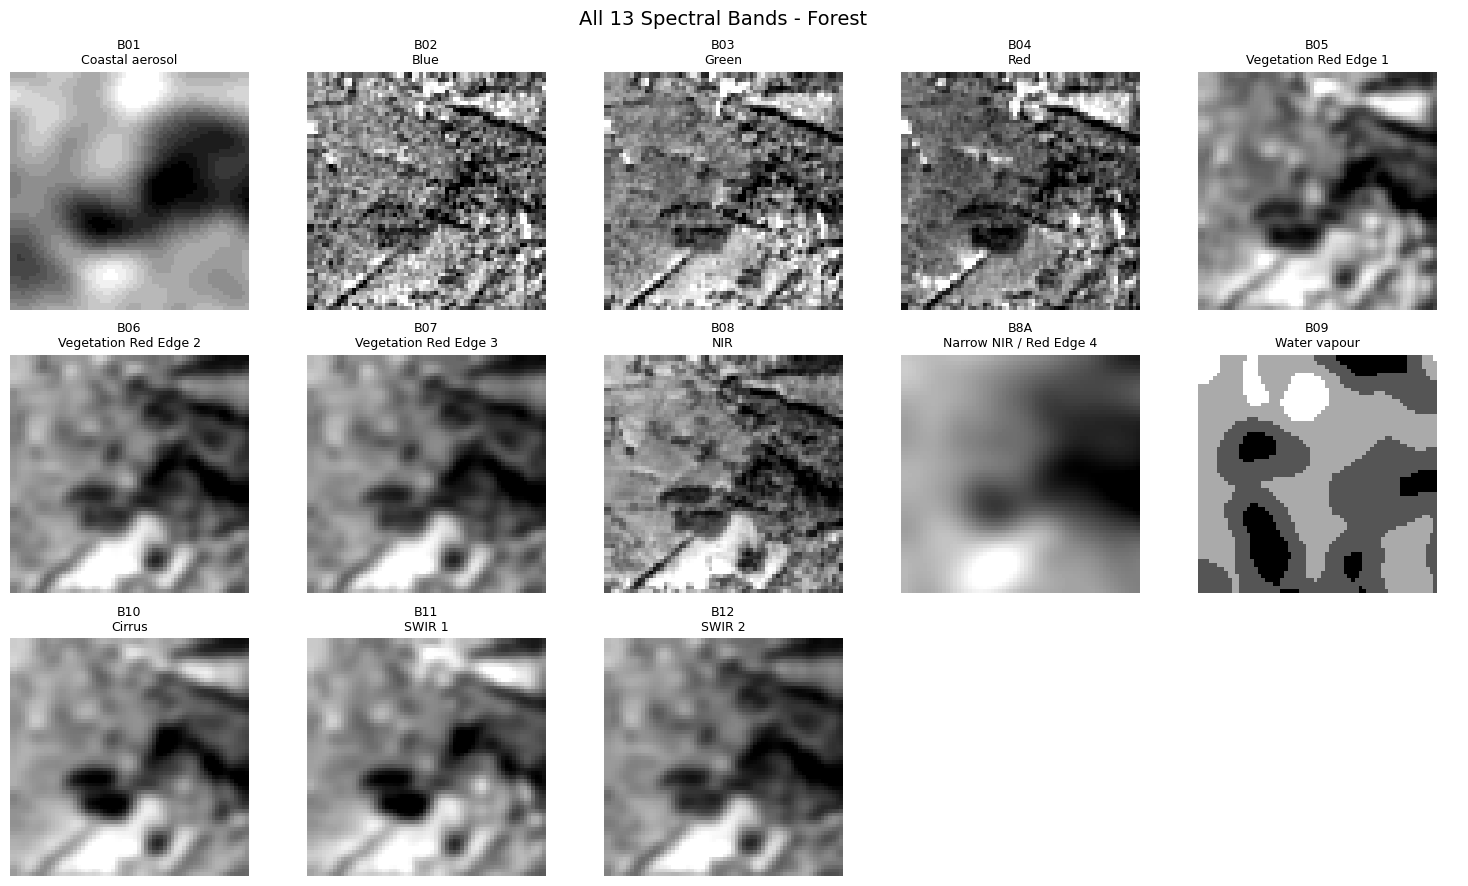

In [56]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
axes = axes.flatten()

for i in range(len(axes)):
    ax = axes[i]
    if i < img.shape[0]:
        ax.imshow(normalize_band(img[i]), cmap="gray")
        ax.set_title(f"{band_names[i]}\n{band_long_names[i]}", fontsize=9)
        ax.axis("off")
    else:
        ax.axis("off")

plt.suptitle(f"All 13 Spectral Bands - {label}", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Plot the mean spectral signature of the sample

This is a compact way to summarize multispectral information.  
For this single image, we compute the **mean pixel value of each band** and plot it against the corresponding wavelength.


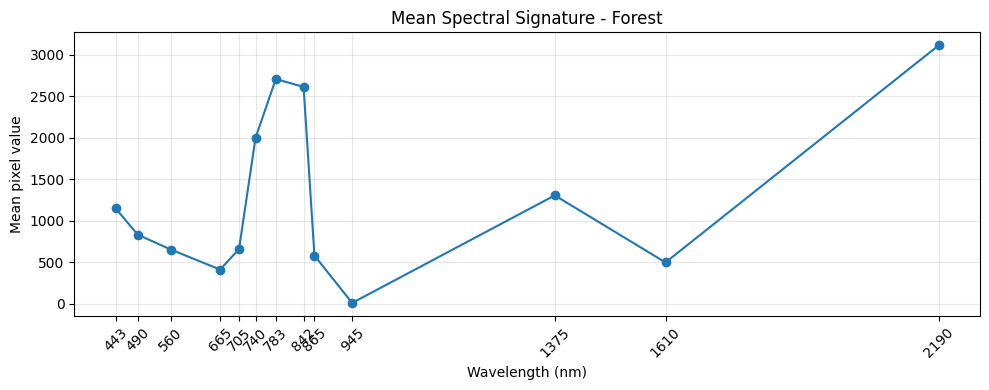

In [57]:
mean_spectrum = [img[i].mean() for i in range(img.shape[0])]

plt.figure(figsize=(10, 4))
plt.plot(wavelengths_nm, mean_spectrum, marker="o")
plt.xticks(wavelengths_nm, rotation=45)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Mean pixel value")
plt.title(f"Mean Spectral Signature - {label}")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Plot pixel value distributions of selected bands

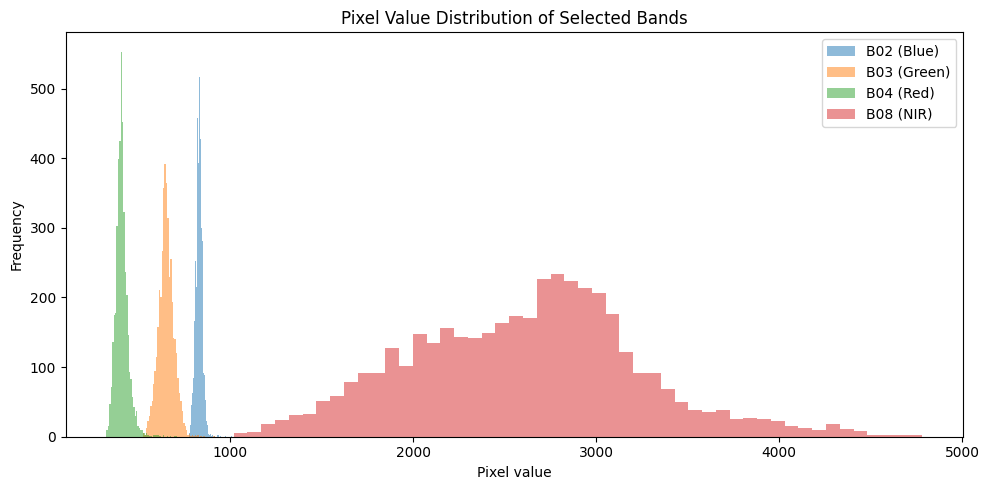

In [58]:
plt.figure(figsize=(10, 5))

selected_bands = {
    "B02 (Blue)": img[1],
    "B03 (Green)": img[2],
    "B04 (Red)": img[3],
    "B08 (NIR)": img[7],
}

for name, band in selected_bands.items():
    plt.hist(band.ravel(), bins=50, alpha=0.5, label=name)

plt.title("Pixel Value Distribution of Selected Bands")
plt.xlabel("Pixel value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Inspect correlation between spectral bands

Band correlation helps us see which channels carry similar information and which may contribute more distinct spectral cues.


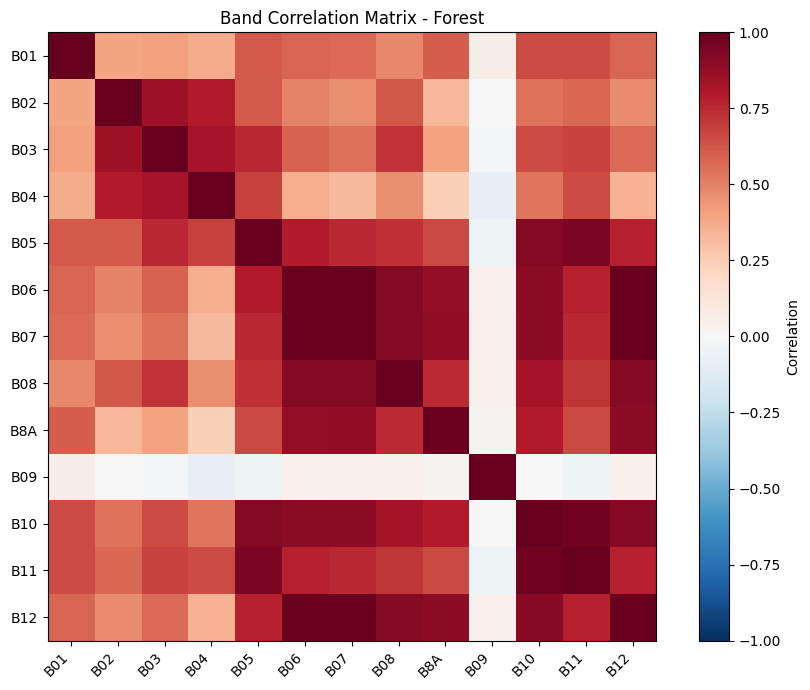

In [59]:
band_flat = img.reshape(img.shape[0], -1)
corr_matrix = np.corrcoef(band_flat)

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(band_names)))
ax.set_yticks(range(len(band_names)))
ax.set_xticklabels(band_names, rotation=45, ha="right")
ax.set_yticklabels(band_names)
ax.set_title(f"Band Correlation Matrix - {label}")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")

plt.tight_layout()
plt.show()

## Observations

- Each EuroSAT-MS sample is a **13-channel multispectral GeoTIFF**.
- The sample used here has shape `(13, 64, 64)` and data type `uint16`.
- The natural-color RGB view is built from **B04, B03, B02**.
- The false-color view (**B08, B04, B03**) is useful because NIR often highlights vegetation more clearly than RGB.
- The 13 bands span a wide spectral range, from **coastal/visible** to **NIR** and **SWIR**, which is why EuroSAT-MS contains richer information than RGB-only imagery.
- The mean spectral signature shows that each image is not just a picture, but a stack of measurements across wavelengths.
- Histogram and correlation analysis help explain why some bands may behave similarly while others contribute complementary information.
- This exploration confirms the expected input format for later steps: **13-band image + label**, with RGB extracted only when needed for visualization or the CLIP-RGB baseline.
